In [7]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Relative path to read the CSV file 
data=pd.read_csv("pizza_sales.csv")
display(data)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1.0,1.0,hawaiian_m,1.0,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2.0,2.0,classic_dlx_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3.0,2.0,five_cheese_l,1.0,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4.0,2.0,ital_supr_l,1.0,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5.0,2.0,mexicana_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616.0,21348.0,ckn_alfredo_m,1.0,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617.0,21348.0,four_cheese_l,1.0,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618.0,21348.0,napolitana_s,1.0,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619.0,21349.0,mexicana_l,1.0,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [3]:
# To find the columns and Rows
data.shape

(48620, 12)

In [4]:
# DATA CLEANING
# Data structure and types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  float64
 1   order_id           48620 non-null  float64
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  float64
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(5), object(7)
memory usage: 4.5+ MB


In [5]:
# Data type changing
# Convert 'pizza_id and order_id' column to object format
data["pizza_id"] = data["pizza_id"].astype("str")
data["order_id"] = data["order_id"].astype("str")
# Convert 'quantity' column to integer format
data["quantity"] = data["quantity"].astype(int)
# Convert 'order_date' column to datetime format
data["order_date"]=pd.to_datetime(data["order_date"],format="mixed")
# Convert 'order_time' column to datetime format
data["order_time"]=pd.to_datetime(data["order_time"],format="mixed")

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pizza_id           48620 non-null  object        
 1   order_id           48620 non-null  object        
 2   pizza_name_id      48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  datetime64[ns]
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
dtypes: datetime64[ns](2), float64(2), int64(1), object(7)
memory usage: 4.5+ MB


In [7]:
for col in data.columns:
    
    if data[col].dtype in ["float64", "int64"]:
        print(f"Feature: {col}")
        print("Min:", data[col].min())
        print("Max:", data[col].max())
        print()
        
    else:
        print(f"Feature: {col}")
        print("Unique Values:", data[col].unique())
        print("No. of Unique Values:", data[col].nunique())
        print()

Feature: pizza_id
Unique Values: ['1.0' '2.0' '3.0' ... '48618.0' '48619.0' '48620.0']
No. of Unique Values: 48620

Feature: order_id
Unique Values: ['1.0' '2.0' '3.0' ... '21348.0' '21349.0' '21350.0']
No. of Unique Values: 21350

Feature: pizza_name_id
Unique Values: ['hawaiian_m' 'classic_dlx_m' 'five_cheese_l' 'ital_supr_l' 'mexicana_m'
 'thai_ckn_l' 'ital_supr_m' 'prsc_argla_l' 'bbq_ckn_s' 'the_greek_s'
 'spinach_supr_s' 'classic_dlx_s' 'green_garden_s' 'ital_cpcllo_l'
 'ital_supr_s' 'mexicana_s' 'spicy_ital_l' 'spin_pesto_l' 'veggie_veg_s'
 'mexicana_l' 'southw_ckn_l' 'bbq_ckn_l' 'cali_ckn_l' 'cali_ckn_m'
 'pepperoni_l' 'cali_ckn_s' 'ckn_pesto_l' 'big_meat_s' 'soppressata_l'
 'four_cheese_l' 'napolitana_s' 'calabrese_m' 'four_cheese_m'
 'ital_veggie_s' 'mediterraneo_m' 'peppr_salami_s' 'spinach_fet_l'
 'napolitana_l' 'sicilian_l' 'ital_cpcllo_m' 'southw_ckn_s' 'bbq_ckn_m'
 'pepperoni_m' 'prsc_argla_s' 'sicilian_m' 'veggie_veg_l' 'ckn_alfredo_s'
 'pepperoni_s' 'green_garden_l' 'gr

In [8]:
# Checking for missing values
data.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [67]:
# Checking duplicate values
data.duplicated().sum()

np.int64(0)

In [10]:
# Checking outlier
data.describe()

,quantity,order_date,order_time,unit_price,total_price
count,48620.000000,48620,48620,48620.000000,48620.000000
mean,1.019622,2015-06-28 21:56:43.932538112,2026-05-05 16:24:51.322151424,16.494132,16.821474
min,1.000000,2015-01-01 00:00:00,2026-05-05 09:52:21,9.750000,9.750000
25%,1.000000,2015-03-30 00:00:00,2026-05-05 13:24:46,12.750000,12.750000
50%,1.000000,2015-06-28 00:00:00,2026-05-05 16:33:33,16.500000,16.500000
75%,1.000000,2015-09-29 00:00:00,2026-05-05 18:55:19,20.250000,20.500000
max,4.000000,2015-12-31 00:00:00,2026-05-05 23:05:52,35.950000,83.000000
std,0.143077,NaN,NaN,3.621789,4.437398


In [11]:
data.describe(include="object")

,pizza_id,order_id,pizza_name_id,pizza_size,pizza_category,pizza_ingredients,pizza_name
count,48620,48620,48620,48620,48620,48620,48620
unique,48620,21350,91,5,4,32,32
top,1.0,18845.0,big_meat_s,L,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
freq,1,21,1811,18526,14579,2416,2416


In [ ]:
Q1=data["total_price"].quantile(0.25)


<Axes: xlabel='total_price'>

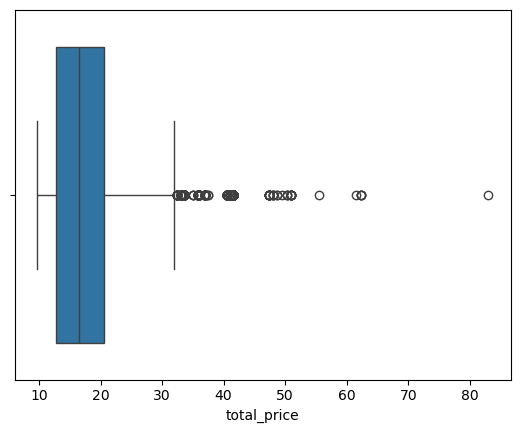

In [12]:
sns.boxplot(data=data,x="total_price")

OBSERVATION:
Yes, there are outliers in total_price Not really a problem because High value comes from multiple quantity orders.


In [13]:
# Exploratory Data Analysis
# What is the total revenue generated over time?
data["total_price"].sum()

np.float64(817860.0499999999)

OBSERVATION:
The dataset shows the total revenue generated, reflecting overall sales performance. This metric helps evaluate business growth and identify further areas for analysis.

In [14]:
# How does revenue vary month-wise?
data["month"] = data["order_date"].dt.month #Create month column
data.groupby("month")["total_price"].sum()

month
1     71620.15
2     64419.45
3     71301.40
4     70312.00
5     67648.80
6     68161.45
7     70880.65
8     69497.30
9     63803.70
10    68152.20
11    71004.85
12    61058.10
Name: total_price, dtype: float64

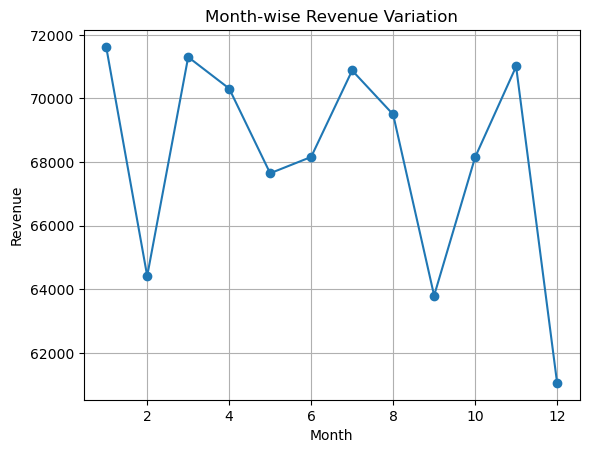

In [15]:
monthly_revenue = data.groupby("month")["total_price"].sum()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Month-wise Revenue Variation")

plt.grid()
plt.show()

OBSERVATION:
The revenue remains relatively stable throughout the year, with slight peaks in January, March, July, and November, indicating consistent demand. A noticeable dip is observed in September and December, which may suggest seasonal slowdown or reduced customer activity.

In [16]:
# Which day in a week sales increased?
data["weekday"] = data["order_date"].dt.day_name()# Create weekday column
data.groupby("weekday")["total_price"].sum()

weekday
Friday       129690.90
Monday       110471.60
Saturday     121605.15
Sunday       102116.45
Thursday     121650.30
Tuesday      115594.45
Wednesday    116731.20
Name: total_price, dtype: float64

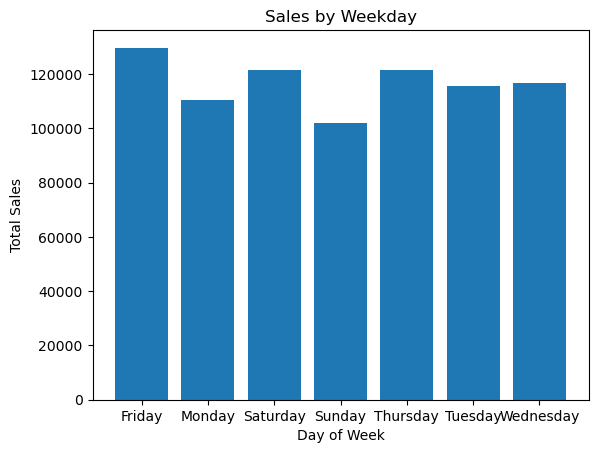

In [17]:
weekday_sales = data.groupby("weekday")["total_price"].sum()
plt.bar(weekday_sales.index, weekday_sales.values)
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.title("Sales by Weekday")
plt.show()

OBSERVATION:
Sales peak on Friday and decline by Sunday, showing a clear weekend-driven customer behavior pattern.


In [18]:
# What is the average order value per day?
data.groupby("order_date")["total_price"].mean()

order_date
2015-01-01    16.856211
2015-01-02    16.963830
2015-01-03    16.146970
2015-01-04    16.367293
2015-01-05    16.920724
                ...    
2015-12-27    16.310345
2015-12-28    16.050980
2015-12-29    17.574675
2015-12-30    18.326027
2015-12-31    17.052632
Name: total_price, Length: 358, dtype: float64

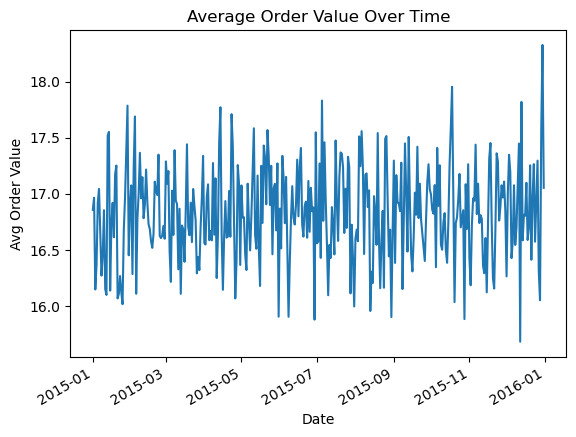

In [19]:
data.groupby("order_date")["total_price"].mean().plot()

plt.title("Average Order Value Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Order Value")
plt.show()

OBSERVATION:
The average order value remains fairly consistent across days, mostly ranging between 16 and 18, indicating stable customer spending behavior. A slight increase is observed towards the end of the year, suggesting higher spending during that period.

In [20]:
# How does quantity sold impact total revenue?
data.groupby('month').agg({"quantity":"sum","total_price":"sum"})

,quantity,total_price
month,,
1,4361,71620.15
2,3893,64419.45
3,4332,71301.40
4,4259,70312.00
5,4083,67648.80
6,4123,68161.45
7,4310,70880.65
8,4222,69497.30
9,3860,63803.70


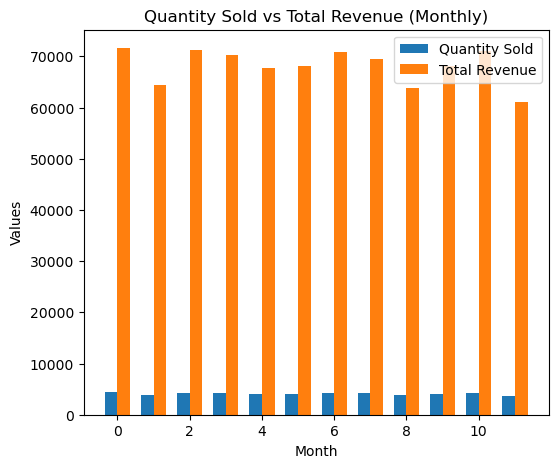

In [21]:
import matplotlib.pyplot as plt
import numpy as np
monthly_data = data.groupby('month').agg({"quantity": "sum","total_price": "sum"})
x = np.arange(len(monthly_data.index))
width = 0.35
plt.figure(figsize=(6, 5))
plt.bar(x - width/2, monthly_data["quantity"], width, label="Quantity Sold")
plt.bar(x + width/2, monthly_data["total_price"], width, label="Total Revenue")
plt.xlabel("Month")
plt.ylabel("Values")
plt.title("Quantity Sold vs Total Revenue (Monthly)")
plt.legend()
plt.show()

OBSERVATION:
There is a clear positive relationship between quantity sold and total revenue, where months with higher quantities consistently generate higher revenue. This indicates that sales volume is a key driver of overall business performance.

In [22]:
# Which time slots generate maximum revenue?
data["hour"] = pd.to_datetime(data["order_time"]).dt.hour # Hour column create
data.groupby("hour")["total_price"].sum()

hour
9         83.00
10       303.65
11     44935.80
12    111877.90
13    106065.70
14     59201.40
15     52992.30
16     70055.40
17     86237.45
18     89296.85
19     72628.90
20     58215.40
21     42029.80
22     22815.15
23      1121.35
Name: total_price, dtype: float64

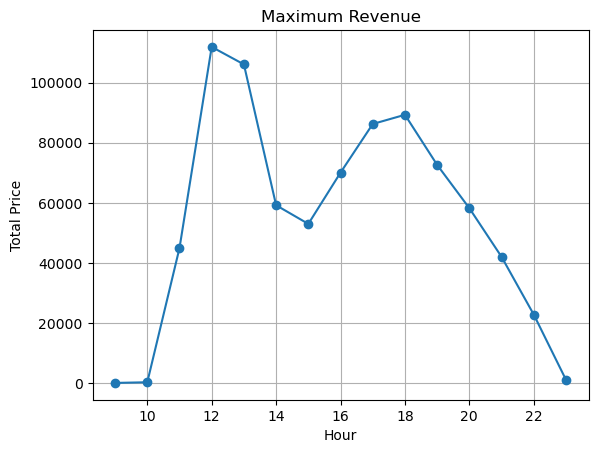

In [23]:
maximum_revenue = data.groupby("hour")["total_price"].sum()
plt.plot(maximum_revenue.index, maximum_revenue.values, marker='o')

plt.xlabel("Hour")
plt.ylabel("Total Price")
plt.title("Maximum Revenue")
plt.grid()
plt.show()

OBSERVATION:
Revenue peaks during lunch hours (12 PM–1 PM) and evening hours (5 PM–7 PM), indicating high customer activity during these time slots. Early morning and late night hours generate significantly lower revenue, showing limited demand.

In [24]:
#What is the revenue contribution by each pizza category?
data.groupby("pizza_category")["total_price"].sum()

pizza_category
Chicken    195919.50
Classic    220053.10
Supreme    208197.00
Veggie     193690.45
Name: total_price, dtype: float64

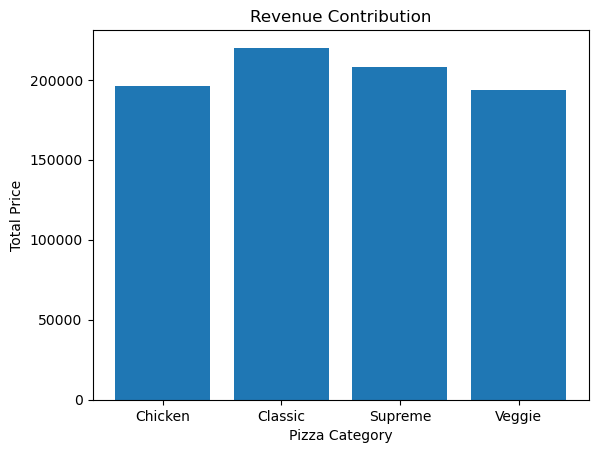

In [25]:
Revenue_contribution = data.groupby("pizza_category")["total_price"].sum()
plt.bar(Revenue_contribution.index, Revenue_contribution.values)
plt.xlabel("Pizza Category")
plt.ylabel("Total Price")
plt.title("Revenue Contribution")
plt.show()

OBSERVATION:
The Classic category generates the highest revenue, followed closely by Supreme, indicating strong customer preference for these types. Chicken and Veggie categories contribute slightly lower but still maintain a balanced share of overall revenue.

In [26]:
# How does revenue fluctuate during weekdays vs weekends?
data["day_type"] = data["weekday"].apply(lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday") # create daytype column
data.groupby(["day_type", "weekday"])["total_price"].sum()

day_type  weekday  
Weekday   Friday       129690.90
          Monday       110471.60
          Thursday     121650.30
          Tuesday      115594.45
          Wednesday    116731.20
Weekend   Saturday     121605.15
          Sunday       102116.45
Name: total_price, dtype: float64

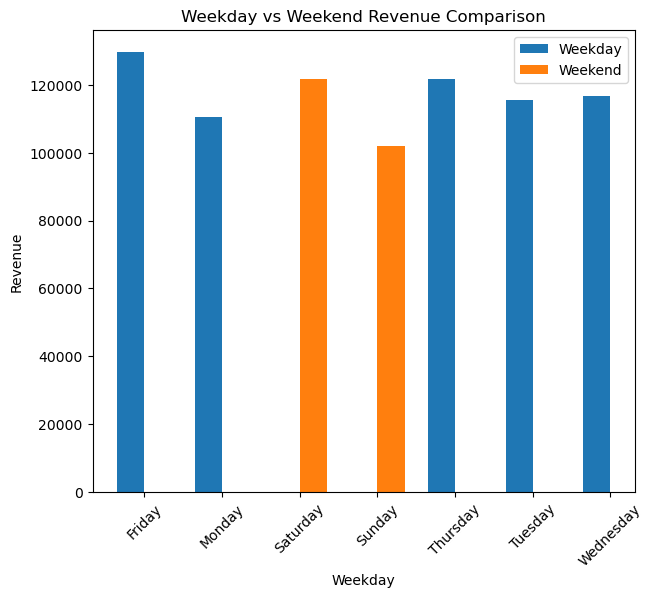

In [27]:
import numpy as np

import matplotlib.pyplot as plt

# Create summary table
summary = data.groupby(["day_type", "weekday"])["total_price"].sum().unstack()

x = np.arange(len(summary.columns))
width = 0.35

plt.figure(figsize=(7,6))

plt.bar(x - width/2, summary.loc["Weekday"], width, label="Weekday")
plt.bar(x + width/2, summary.loc["Weekend"], width, label="Weekend")

plt.xticks(x, summary.columns, rotation=45)

plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.title("Weekday vs Weekend Revenue Comparison")

plt.legend()
plt.show()

OBSERVATION:
Revenue is generally higher on weekdays, with Friday generating the highest sales, indicating strong end-of-week demand. While weekends also contribute significantly, Sunday shows a noticeable drop compared to other days

In [72]:
# What is the trend of sales growth over time?
data.groupby("order_date")["total_price"].sum()

order_date
2015-01-01    2713.85
2015-01-02    3189.20
2015-01-03    1598.55
2015-01-04    2176.85
2015-01-05    2571.95
               ...   
2015-12-27    1419.00
2015-12-28    1637.20
2015-12-29    1353.25
2015-12-30    1337.80
2015-12-31    2916.00
Name: total_price, Length: 358, dtype: float64

OBSERVATION:
Sales fluctuate daily with occasional spikes, indicating inconsistent short-term trends but possible seasonal peaks.


<Axes: xlabel='order_id'>

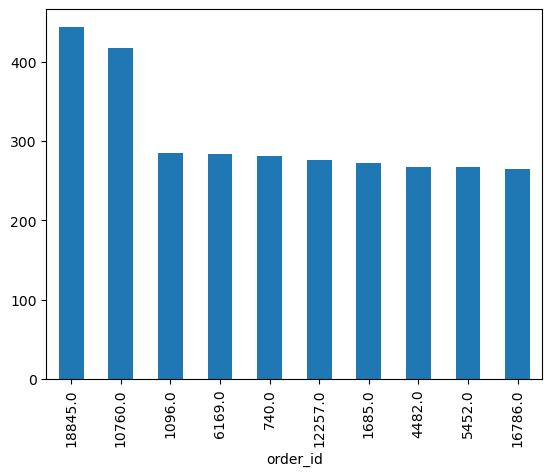

In [29]:
# Which orders contribute most to overall revenue?
data.groupby("order_id")["total_price"].sum().sort_values(ascending=False).head(10).plot(kind="bar")

OBSERVATION:
The analysis shows that a few high-value orders contribute significantly more revenue than typical orders, indicating the importance of bulk or premium purchases in driving overall sales.

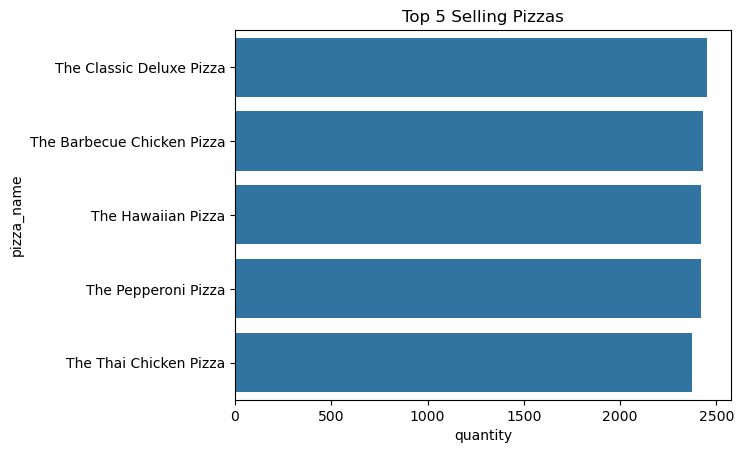

In [30]:
# Which pizzas are the top-selling products?
import seaborn as sns
top_pizzas=data.groupby("pizza_name")["quantity"].sum().sort_values(ascending=False).head(5).reset_index()
sns.barplot(data=top_pizzas, x="quantity", y="pizza_name")
plt.title("Top 5 Selling Pizzas")
plt.show()

In [79]:
data.groupby("pizza_name")["unit_price"].mean().sort_values(ascending=False)

pizza_name
The Brie Carre Pizza                          23.650000
The Greek Pizza                               20.035633
The Five Cheese Pizza                         18.500000
The Thai Chicken Pizza                        18.286069
The Spicy Italian Pizza                       18.104663
The Southwest Chicken Pizza                   18.080504
The Mexicana Pizza                            18.024038
The Italian Supreme Pizza                     17.769740
The Pepper Salami Pizza                       17.637834
The Barbecue Chicken Pizza                    17.572934
The California Chicken Pizza                  17.448523
The Italian Capocollo Pizza                   17.426803
The Chicken Pesto Pizza                       17.153746
The Chicken Alfredo Pizza                     17.121429
The Soppressata Pizza                         17.077064
The Calabrese Pizza                           17.005124
The Four Cheese Pizza                         16.951946
The Prosciutto and Arugula Pizza     

OBSERVATION:

The Classic Deluxe Pizza is the most sold item, closely followed by Barbecue Chicken and Hawaiian pizzas, indicating consistent customer preference across these varieties.

<Axes: ylabel='pizza_name'>

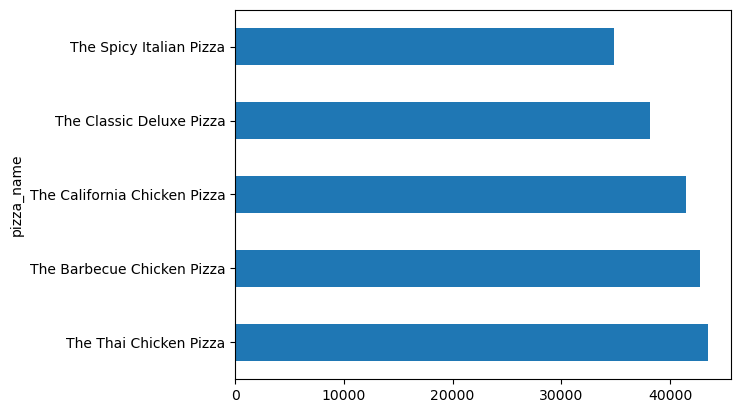

In [31]:
# Which pizzas generate the highest revenue?
c=data.groupby("pizza_name")["total_price"].sum().sort_values(ascending=False).head(5).plot(kind="barh")

OBSERVATION:
Chicken-based pizzas dominate revenue, with Thai Chicken Pizza leading the sales.Some pizzas like Classic Deluxe are high in demand but not the highest revenue generators, while pizzas like Thai Chicken generate higher revenue despite slightly lower quantity, indicating a pricing impact.

In [32]:
# Which pizzas have high quantity but low revenue?
pizza_stats = data.groupby("pizza_name").agg({"quantity": "sum","total_price": "sum"})
pizza_stats["avg_price"] = pizza_stats["total_price"] / pizza_stats["quantity"]
pizza_stats.sort_values(by=["quantity", "avg_price"],ascending=[False, True]).head(10)

,quantity,total_price,avg_price
pizza_name,,,
The Classic Deluxe Pizza,2453,38180.50,15.564819
The Barbecue Chicken Pizza,2432,42768.00,17.585526
The Hawaiian Pizza,2422,32273.25,13.325041
The Pepperoni Pizza,2418,30161.75,12.473842
The Thai Chicken Pizza,2371,43434.25,18.318958
The California Chicken Pizza,2370,41409.50,17.472363
The Sicilian Pizza,1938,30940.50,15.965170
The Spicy Italian Pizza,1924,34831.25,18.103560
The Southwest Chicken Pizza,1917,34705.75,18.104199


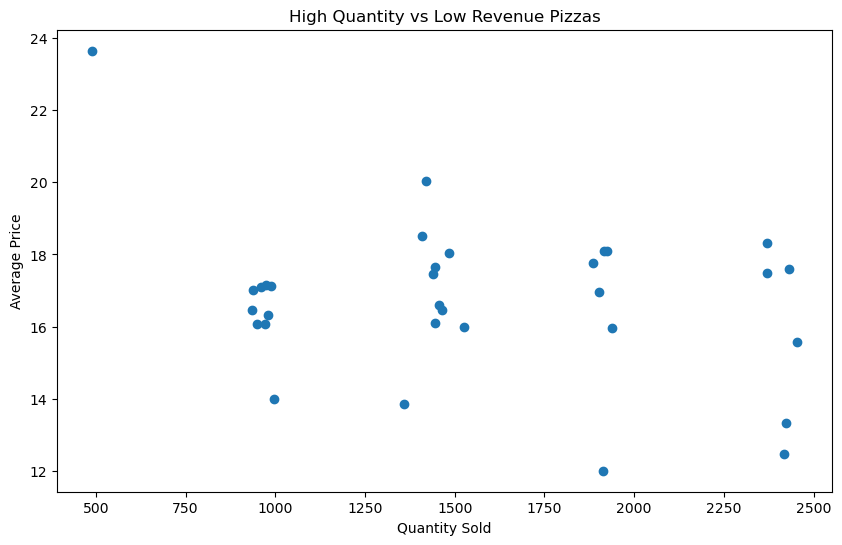

In [81]:
plt.figure(figsize=(10,6))

plt.scatter(pizza_stats["quantity"], pizza_stats["avg_price"])

plt.xlabel("Quantity Sold")
plt.ylabel("Average Price")
plt.title("High Quantity vs Low Revenue Pizzas")

plt.show()

OBSERVATION:
Pizzas like Classic Deluxe and Hawaiian have high sales volume but relatively lower average price, indicating they are popular low-priced items. In contrast, pizzas like Thai Chicken and Spicy Italian generate higher revenue due to premium pricing despite slightly lower quantities.

In [83]:
# Which pizza categories perform best overall?
data.groupby("pizza_category").agg({"order_id":"count","total_price":"sum"}).sort_values(by="total_price", ascending=False)

,order_id,total_price
pizza_category,,
Classic,14579,220053.10
Supreme,11777,208197.00
Chicken,10815,195919.50
Veggie,11449,193690.45


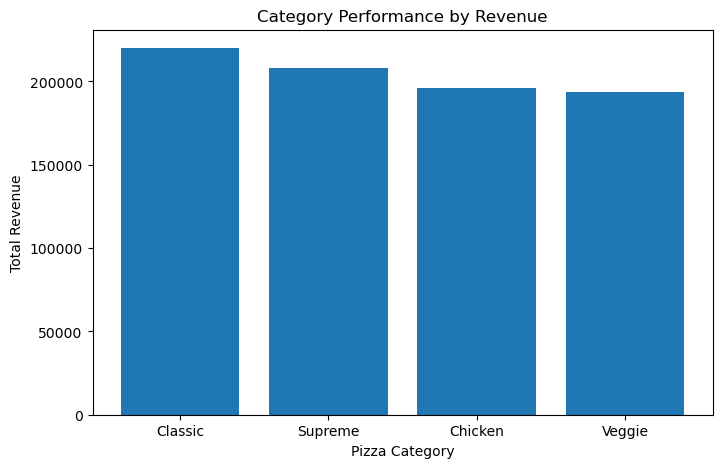

In [84]:
import matplotlib.pyplot as plt

category_perf = data.groupby("pizza_category").agg({
    "order_id": "count",
    "total_price": "sum"
}).sort_values(by="total_price", ascending=False)

# Plot revenue
plt.figure(figsize=(8,5))
plt.bar(category_perf.index, category_perf["total_price"])

plt.xlabel("Pizza Category")
plt.ylabel("Total Revenue")
plt.title("Category Performance by Revenue")

plt.show()

OBSERVATION:
The Classic category leads in both order volume and total revenue, making it the top-performing category. Other categories like Supreme and Chicken also contribute significantly, indicating balanced customer demand across categories.

In [34]:
# Which pizza sizes are most preferred by customers?
data.groupby("pizza_size")["quantity"].sum().sort_values(ascending=False)

pizza_size
L      18956
M      15635
S      14403
XL       552
XXL       28
Name: quantity, dtype: int64

OBSERVATION:
Large (L) pizzas are the most preferred by customers, contributing the highest quantity sold, followed by Medium and Small sizes. Extra-large sizes (XL and XXL) have very low demand, indicating limited customer preference for oversized portions.

In [35]:
# What is the revenue contribution of each pizza size?
data.groupby("pizza_size")["total_price"].sum()

pizza_size
L      375318.70
M      249382.25
S      178076.50
XL      14076.00
XXL      1006.60
Name: total_price, dtype: float64

OBSERVATION:
Large-sized pizzas contribute the highest share of revenue, followed by Medium and Small sizes, indicating strong customer preference for larger portions. Extra-large sizes (XL and XXL) contribute very minimally, showing low demand and limited revenue impact.

In [36]:
# Which pizzas are consistently low-performing?
data.groupby("pizza_name").agg({"quantity":"sum","total_price":"sum"}).sort_values(by="total_price").head(5)

,quantity,total_price
pizza_name,,
The Brie Carre Pizza,490,11588.50
The Green Garden Pizza,997,13955.75
The Spinach Supreme Pizza,950,15277.75
The Mediterranean Pizza,934,15360.50
The Spinach Pesto Pizza,970,15596.00


OBSERVATION:
Pizzas like Brie Carre and Green Garden show low sales volume and low revenue, indicating weak customer demand. These items consistently underperform compared to others and contribute minimally to overall business revenue.

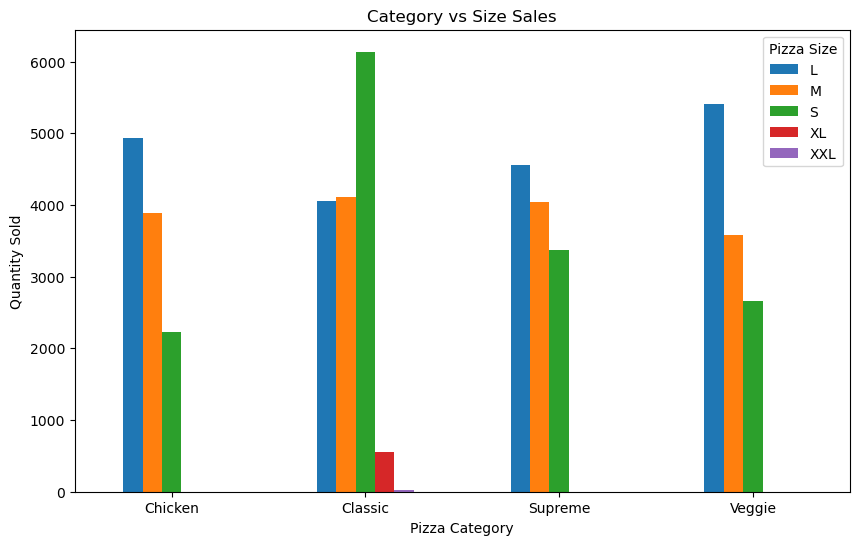

In [80]:
# Which category-size combination sells the most?
combo = data.groupby(["pizza_category","pizza_size"])["quantity"].sum().unstack()

combo.plot(kind="bar", figsize=(10,6))

plt.xlabel("Pizza Category")
plt.ylabel("Quantity Sold")
plt.title("Category vs Size Sales")

plt.xticks(rotation=0)
plt.legend(title="Pizza Size")

plt.show()

OBSERVATION:
The analysis shows that small-sized Classic pizzas have the highest demand, while large sizes dominate in other categories, indicating that customer preferences vary based on both category and portion size.

In [38]:
# What is the average price per pizza across categories?
data.groupby("pizza_category")["unit_price"].mean()

pizza_category
Chicken    17.709408
Classic    14.797490
Supreme    17.363229
Veggie     16.612639
Name: unit_price, dtype: float64

OBSERVATION:
Chicken pizzas have the highest average price, while Classic pizzas are the cheapest.
Supreme and Veggie pizzas fall in the mid-price range with similar values.

In [39]:
# At what time do customers place the most orders?
data.groupby("hour")["order_id"].count().sort_values(ascending=False).head(5)

hour
12    6543
13    6203
18    5359
17    5143
19    4350
Name: order_id, dtype: int64

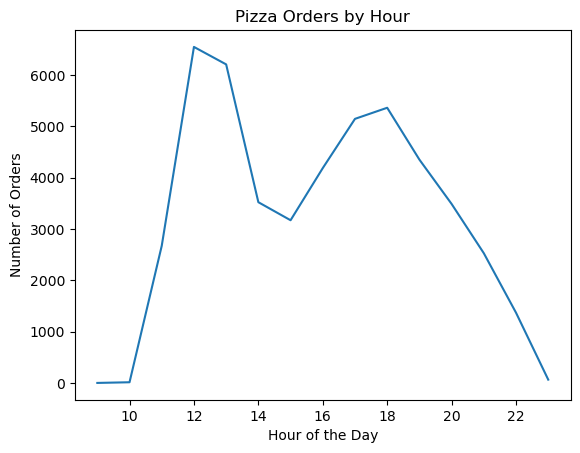

In [40]:
import matplotlib.pyplot as plt

hourly_orders = data.groupby("hour")["order_id"].count().sort_index()

plt.plot(hourly_orders.index, hourly_orders.values)
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Orders")
plt.title("Pizza Orders by Hour")
plt.show()

OBSERVATION:
Most orders are placed around lunch time (12–13 hrs), with the highest at 12 PM.
Evening hours (17–19 hrs) also show high demand, especially at 6 PM.

In [41]:
# What are the peak ordering days in a week?
data.groupby("weekday")["order_id"].count().sort_values(ascending=False)

weekday
Friday       7723
Saturday     7274
Thursday     7243
Wednesday    6907
Tuesday      6833
Monday       6577
Sunday       6063
Name: order_id, dtype: int64

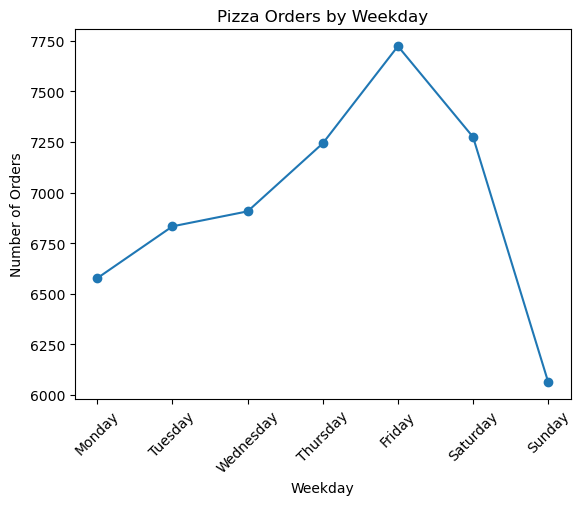

In [42]:
import matplotlib.pyplot as plt

weekday_orders = data.groupby("weekday")["order_id"].count()

# correct order of days
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_orders = weekday_orders.reindex(order)

plt.plot(weekday_orders.index, weekday_orders.values, marker="o")

plt.xlabel("Weekday")
plt.ylabel("Number of Orders")
plt.title("Pizza Orders by Weekday")
plt.xticks(rotation=45)

plt.show()

OBSERVATION:
Peak ordering days are Friday and Saturday, with the highest number of orders.
This shows that customers prefer ordering pizza more during weekends compared to weekdays.

In [43]:
# What is the average number of pizzas per order?
data.groupby("order_id")["quantity"].sum().mean()

np.float64(2.321967213114754)

OBSERVATION:
On average, customers order about 2.32 pizzas per order.
This means most people typically buy 2 to 3 pizzas per order.

In [44]:
# Do customers prefer certain pizza sizes at specific times?
data.groupby(["hour","pizza_size"])["quantity"].sum().unstack()

pizza_size,L,M,S,XL,XXL
hour,,,,,
9,3.0,NaN,NaN,1.0,NaN
10,7.0,8.0,3.0,NaN,NaN
11,1036.0,865.0,787.0,37.0,3.0
12,2633.0,2132.0,1953.0,55.0,3.0
13,2498.0,2032.0,1812.0,69.0,2.0
14,1355.0,1109.0,1111.0,37.0,1.0
15,1190.0,1037.0,950.0,37.0,2.0
16,1632.0,1316.0,1236.0,49.0,6.0
17,2010.0,1627.0,1503.0,70.0,1.0


OBSERVATION:
Customers mostly prefer Large (L) pizzas at all times, followed by Medium (M) and Small (S).
Demand is highest during lunch (12–1 PM) and evening (5–7 PM) across all sizes.
XL and XXL pizzas are rarely ordered, regardless of time

In [45]:
# What ordering patterns are seen during weekends vs weekdays?
data.groupby("day_type")["order_id"].count()

day_type
Weekday    35283
Weekend    13337
Name: order_id, dtype: int64

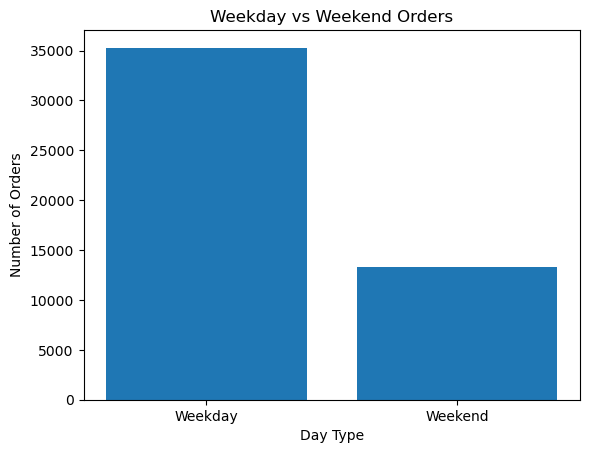

In [46]:
import matplotlib.pyplot as plt

orders = data.groupby("day_type")["order_id"].count()

plt.bar(orders.index, orders.values)

plt.xlabel("Day Type")
plt.ylabel("Number of Orders")
plt.title("Weekday vs Weekend Orders")

plt.show()

OBSERVATION:
Total orders are higher on weekdays (35,283) compared to weekends (13,337).
However, this may be because there are more weekdays than weekend days in the dataset.

In [47]:
# Are customers ordering more during lunch or dinner hours?
# time slot created
data["time_slot"] = data["hour"].apply(lambda x: "Lunch" if 11<=x<=15 else "Dinner")

In [48]:
data.groupby("time_slot")["order_id"].count()

time_slot
Dinner    26511
Lunch     22109
Name: order_id, dtype: int64

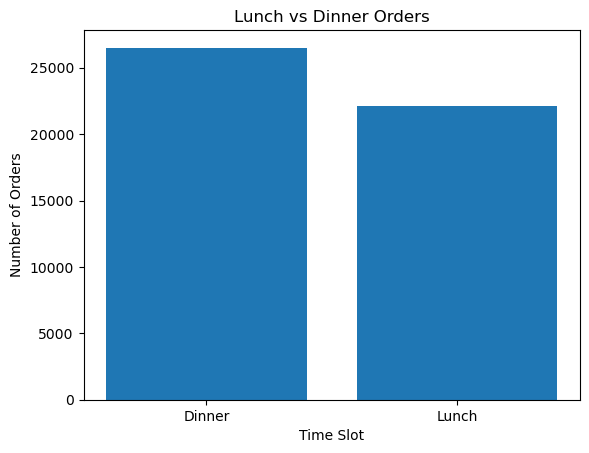

In [49]:
import matplotlib.pyplot as plt

orders = data.groupby("time_slot")["order_id"].count()

plt.bar(orders.index, orders.values)

plt.xlabel("Time Slot")
plt.ylabel("Number of Orders")
plt.title("Lunch vs Dinner Orders")

plt.show()

OBSERVATION:
Customers order more during dinner hours (26,511 orders) compared to lunch (22,109 orders).
This shows higher demand in the evening than during midday.

In [66]:
# Which categories are popular among customers at peak hours?
data.groupby(["hour","pizza_category"])["quantity"].sum().sort_values(ascending=False).head(5)


hour  pizza_category
12    Classic           2039
13    Classic           1931
12    Veggie            1637
18    Classic           1632
12    Supreme           1612
Name: quantity, dtype: int64

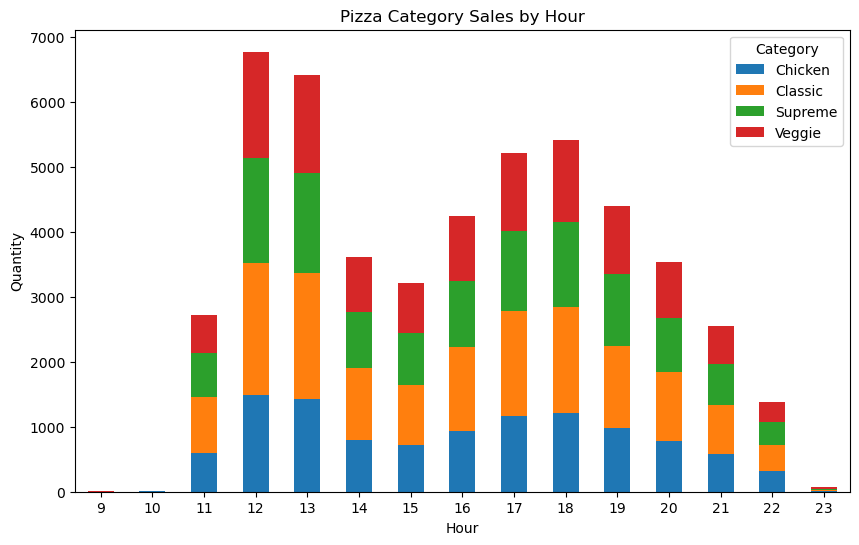

In [63]:
pivot = data.pivot_table(
    index="hour",
    columns="pizza_category",
    values="quantity",
    aggfunc="sum"
)

pivot.plot(kind="bar", stacked=True, figsize=(10,6))

plt.xlabel("Hour")
plt.ylabel("Quantity")
plt.title("Pizza Category Sales by Hour")

plt.xticks(rotation=0)
plt.legend(title="Category")

plt.show()

OBSERVATION:
Classic pizzas are the most popular during peak hours, especially at 12 PM and 1 PM.
Other categories like Veggie and Supreme are also popular, mainly around lunch time.

In [52]:
# What is the repeat pattern in ordering behavior ?
data.groupby("order_id")["pizza_name"].nunique().value_counts()

pizza_name
1     8320
2     6307
3     3444
4     2567
5      142
7       95
6       91
9       84
8       79
10      76
11      71
12      45
13      22
14       4
18       1
15       1
17       1
Name: count, dtype: int64

OBSERVATION:
Most customers order 1 or 2 different pizzas per order, with 1-item orders being the highest.
Orders with more than 4 different pizzas are rare, showing limited variety per order

In [53]:
# Do customers order more variety or same pizza types?
data.groupby("order_id")["pizza_category"].nunique().mean()

np.float64(1.7527400468384076)

OBSERVATION:
Customers usually order around 1–2 different pizza categories per order.
This means they mostly prefer similar categories with a little variation, not too much variety.

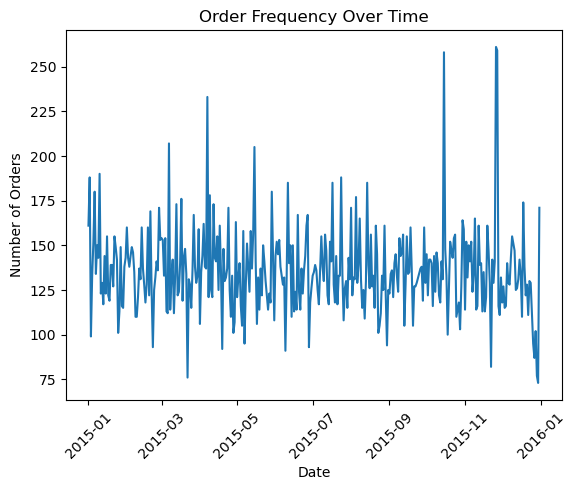

In [54]:
# How does order frequency change over time?
import matplotlib.pyplot as plt

orders = data.groupby("order_date")["order_id"].count()

plt.plot(orders.index, orders.values)

plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.title("Order Frequency Over Time")

plt.xticks(rotation=45)
plt.show()

OBSERVATION:
Order frequency changes over time, showing daily fluctuations in demand.
Some days have higher peaks, while others show lower order activity.

In [55]:
# Which pizzas should be promoted to increase revenue?
data.groupby("pizza_name")[["quantity","total_price"]].sum().sort_values(by="quantity", ascending=True)

,quantity,total_price
pizza_name,,
The Brie Carre Pizza,490,11588.50
The Mediterranean Pizza,934,15360.50
The Calabrese Pizza,937,15934.25
The Spinach Supreme Pizza,950,15277.75
The Soppressata Pizza,961,16425.75
The Spinach Pesto Pizza,970,15596.00
The Chicken Pesto Pizza,973,16701.75
The Italian Vegetables Pizza,981,16019.25
The Chicken Alfredo Pizza,987,16900.25


OBSERVATION:
Pizzas with low sales quantity should be promoted to improve their performance.
Increasing their visibility or offering deals can help boost overall revenue.

In [56]:
# Which low-performing pizzas need improvement or removal?
data.groupby("pizza_name")["total_price"].sum().sort_values().head(5)

pizza_name
The Brie Carre Pizza         11588.50
The Green Garden Pizza       13955.75
The Spinach Supreme Pizza    15277.75
The Mediterranean Pizza      15360.50
The Spinach Pesto Pizza      15596.00
Name: total_price, dtype: float64

OBSERVATION:
The Brie Carre Pizza and The Green Garden Pizza are the lowest-performing in terms of revenue.
These pizzas may need promotion, improvement, or possible removal to optimize sales.

In [57]:
data.groupby("hour")["order_id"].count().sort_values().head(5)

hour
9        4
10      17
23      68
22    1370
21    2528
Name: order_id, dtype: int64

In [58]:
# What pricing changes can improve overall revenue?
# Group data
analysis = data.groupby("pizza_name").agg({
    "quantity": "sum",
    "total_price": "sum",
    "unit_price": "mean"
})

# Create categories based on demand & price
analysis["strategy"] = analysis.apply(
    lambda x: "Increase Price" if x["quantity"] > analysis["quantity"].mean() and x["unit_price"] < analysis["unit_price"].mean()
    else ("Discount/Promote" if x["quantity"] < analysis["quantity"].mean() and x["unit_price"] > analysis["unit_price"].mean()
    else "Keep Same"),
    axis=1
)

# Sort for better view
result = analysis.sort_values(by="quantity", ascending=False)

display(result.head(10))

,quantity,total_price,unit_price,strategy
pizza_name,,,,
The Classic Deluxe Pizza,2453,38180.50,15.575952,Increase Price
The Barbecue Chicken Pizza,2432,42768.00,17.572934,Keep Same
The Hawaiian Pizza,2422,32273.25,13.317194,Increase Price
The Pepperoni Pizza,2418,30161.75,12.468658,Increase Price
The Thai Chicken Pizza,2371,43434.25,18.286069,Keep Same
The California Chicken Pizza,2370,41409.50,17.448523,Keep Same
The Sicilian Pizza,1938,30940.50,15.963831,Increase Price
The Spicy Italian Pizza,1924,34831.25,18.104663,Keep Same
The Southwest Chicken Pizza,1917,34705.75,18.080504,Keep Same


OBSERVATION:
Pricing can be optimized by increasing prices for high-demand pizzas and offering discounts on low-demand pizzas.

In [59]:
# Which time periods should discounts be offered?
data.groupby("hour")["order_id"].count().sort_values().head()

hour
9        4
10      17
23      68
22    1370
21    2528
Name: order_id, dtype: int64

OBSERVATION:
Lowest orders occur at 9 AM, 10 AM, and late night (10–11 PM).
So, discounts should be offered during these off-peak hours to increase sales.

In [60]:
# Which pizza size should be marketed more for profit?
size_profit = (
    data.groupby("pizza_size")["total_price"]
    .sum()
    .sort_values(ascending=False)
)
display(size_profit)

pizza_size
L      375318.70
M      249382.25
S      178076.50
XL      14076.00
XXL      1006.60
Name: total_price, dtype: float64

OBSERVATION:
Large (L) size pizzas generate the highest revenue, followed by Medium and Small.
So, large-sized pizzas should be marketed more to maximize profit.


In [61]:
# What product combinations can increase order value?
data.groupby("order_id")["pizza_name"].apply(list).head()


order_id
1.0                                     [The Hawaiian Pizza]
10.0       [The Mexicana Pizza, The Southwest Chicken Pizza]
100.0                                   [The Hawaiian Pizza]
1000.0       [The Brie Carre Pizza, The Mediterranean Pizza]
10000.0    [The Barbecue Chicken Pizza, The Mexicana Pizz...
Name: pizza_name, dtype: object

OBSERVATION:
Customers often order more than one pizza in a single order, showing combination behavior.
Common pairings (like Mexicana + Chicken pizzas) can be turned into combo deals to increase order value.